In [3]:
import pickle

with open('/Users/ksc/PycharmProjects/hot_detector/precomputed_embeddings/train_embs_no_rs.pickle', 'rb') as f:
    data = pickle.load(f)
data['embeddings']

array([[-0.18145126, -0.3755938 , -0.09512956, ...,  0.13613832,
        -0.07053672,  0.03377846],
       [-0.24516192, -0.10938454,  0.1930002 , ..., -0.18837455,
        -0.16570385,  0.18845274],
       [ 0.12373488, -0.30722043, -0.19228624, ..., -0.10843356,
         0.09552593,  0.1544202 ],
       ...,
       [-0.06188963, -0.05984594,  0.10375999, ...,  0.05170614,
        -0.07325178, -0.06683118],
       [ 0.1717709 ,  0.12582824, -0.00390116, ..., -0.07735659,
        -0.0962344 , -0.12051624],
       [-0.12752894,  0.01582951,  0.13704501, ...,  0.04125625,
         0.01607125,  0.01485088]], dtype=float32)

array([0.08 , 0.3  , 0.11 , ..., 0.185, 0.09 , 0.34 ], dtype=float32)

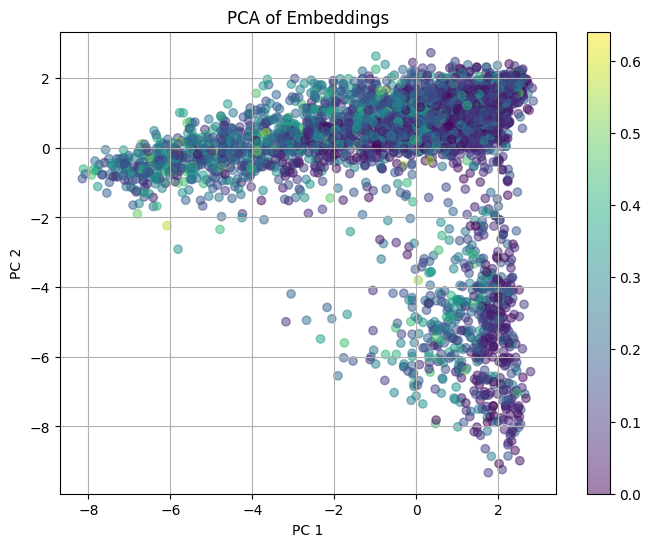

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

embeddings = data['embeddings']
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], alpha=0.5, c=data['targets'])
plt.title('PCA of Embeddings')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.grid(True)
plt.colorbar()
plt.show()



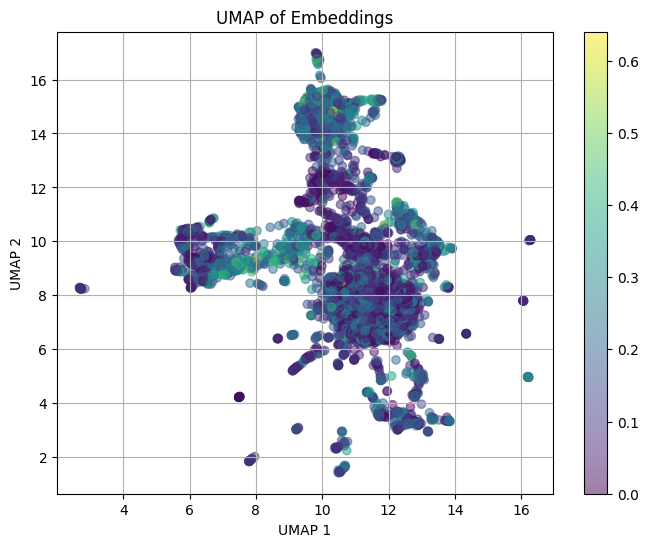

In [19]:
import umap.umap_ as umap  

embeddings = data['embeddings']
reducer = umap.UMAP(n_components=2)
embeddings_umap = reducer.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_umap[:, 0], embeddings_umap[:, 1], alpha=0.5, c=data['targets'])
plt.title('UMAP of Embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)
plt.colorbar()
plt.show()


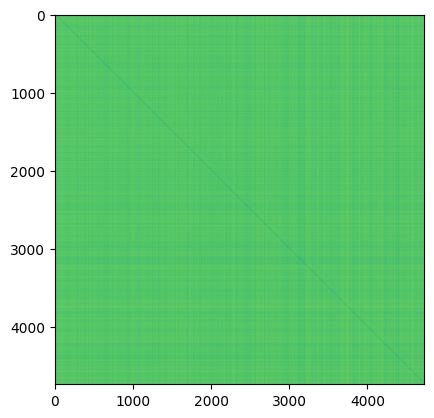

In [31]:
import torch
q = torch.tensor(data['embeddings'])

d = torch.cdist(q, q)
d = d / d.mean()
plt.imshow(d)

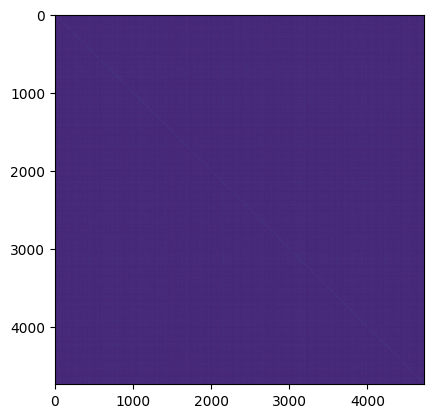

In [23]:
import torch

plt.imshow(data['embeddings'] @ data['embeddings'].T)

In [ ]:
from sklearn.cluster import KMeans

# We'll use the nn embeddings (the data['embeddings'])
embeddings = data['embeddings']

kmeans = KMeans(n_clusters=10, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)

array([1, 1, 2, ..., 7, 7, 1], dtype=int32)

In [42]:
import pandas as pd 

phs = pd.read_csv('/Users/ksc/PycharmProjects/hot_detector/train.csv')['photo_path'].to_list()
phs = ['/Users/ksc/PycharmProjects/hot_detector/photos/' + x.split('/')[-1] for x in phs]

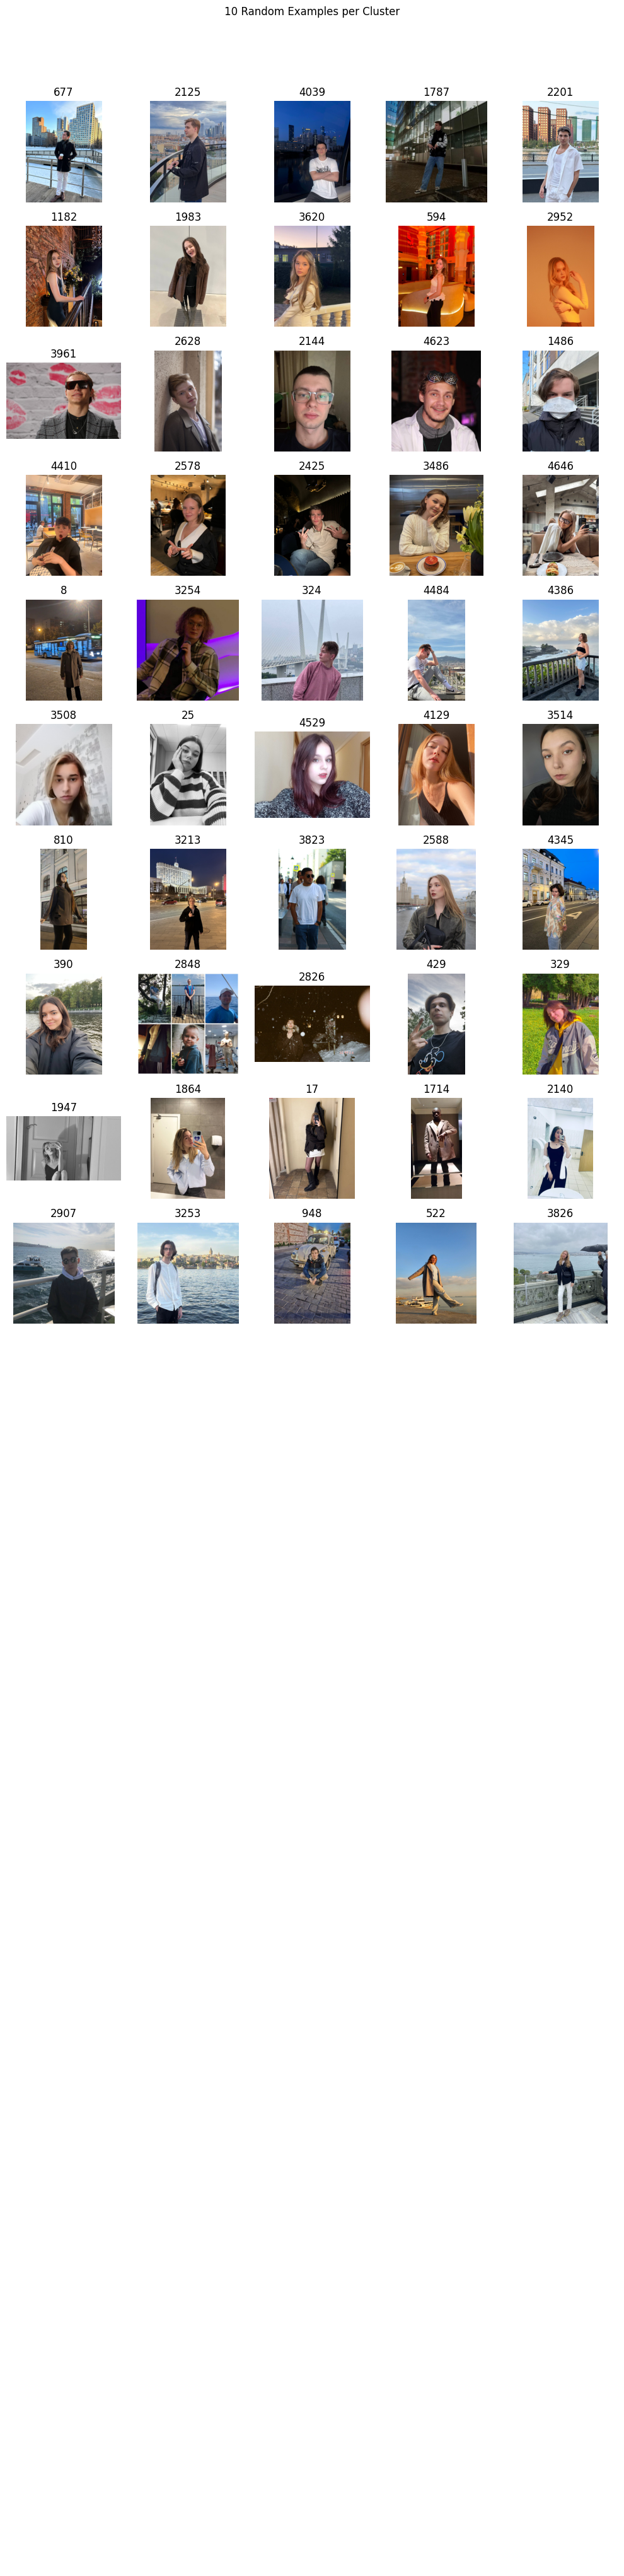

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image

n_clusters = 20
examples_per_cluster = 5

# Dict to store indices for each cluster
cluster_to_indices = {i: np.where(cluster_labels == i)[0] for i in range(n_clusters)}

fig, axs = plt.subplots(n_clusters, examples_per_cluster, figsize=(2*examples_per_cluster, 2*n_clusters))

for cluster in range(n_clusters):
    indices = cluster_to_indices[cluster]
    # Get 10 random indices, or as many as available if <10
    random_indices = np.random.choice(indices, size=min(examples_per_cluster, len(indices)), replace=False)
    for i, idx in enumerate(random_indices):
        img_path = phs[idx]
        img = Image.open(img_path)
        axs[cluster, i].imshow(img)
        axs[cluster, i].axis('off')
        axs[cluster, i].set_title(f'{idx}')
    # If fewer than 10, hide the unused subplots
    for i in range(len(random_indices), examples_per_cluster):
        axs[cluster, i].axis('off')
    # Add cluster label as text on the left of each cluster row
    axs[cluster, 0].set_ylabel(f'Cluster {cluster}', rotation=0, size='large', labelpad=40, va='center')

plt.suptitle("10 Random Examples per Cluster", y=1.02)
plt.tight_layout()
plt.show()
